# Predictive Maintenance: EDA & Modeling
AI4I 2020 dataset: 10,000 machines, about 3.4% of which failed. This notebook walks through Steps 2–8 of the guide and goes further. It reuses the functions in `train.py` and `predict.py`, so the notebook and the production pipeline always match.

In [1]:
import os, sys
os.chdir('..'); sys.path.insert(0, '.')
import pandas as pd
import train, predict
from IPython.display import Image, Markdown, display

## Step 2: Load data

In [2]:
df = train.load_data()
df.describe()

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Step 3: EDA
The histograms and correlations include three engineered features: power (torque × speed), the process–air temperature gap, and strain (wear × torque).


Missing values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Failure rate: 3.39%



Correlation with target:
 Torque Nm                0.191321
Strain                   0.190427
Power W                  0.176039
Tool wear min            0.105448
Air temperature K        0.082556
Process temperature K    0.035946
Rotational speed rpm    -0.044188
Temp diff K             -0.111676
Name: Machine failure, dtype: float64


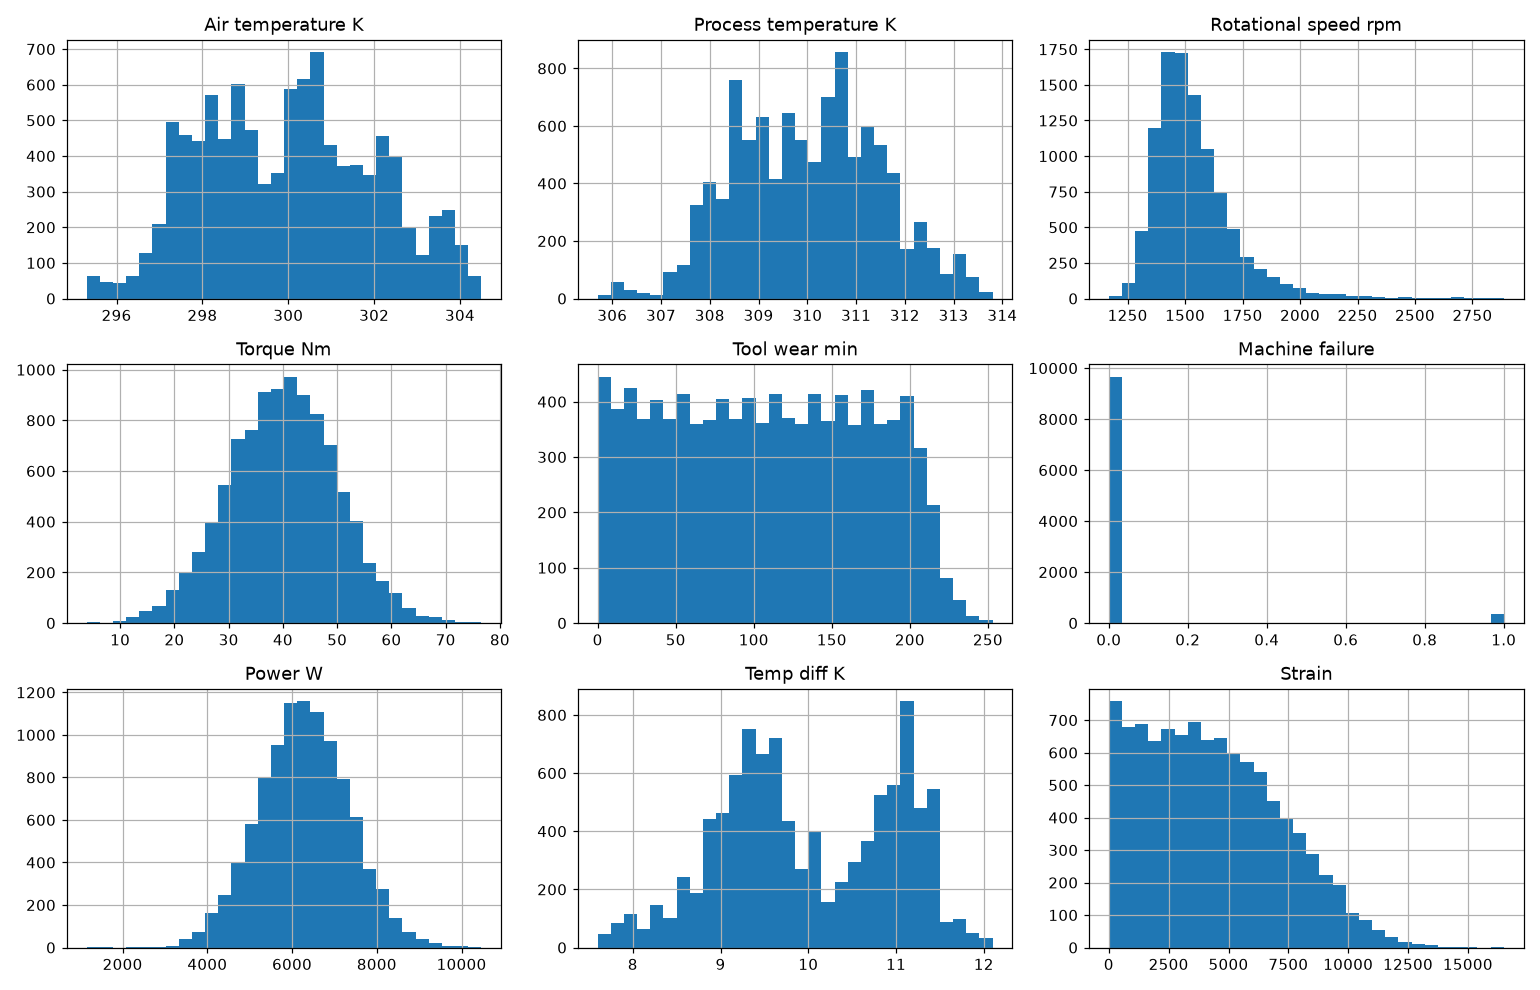

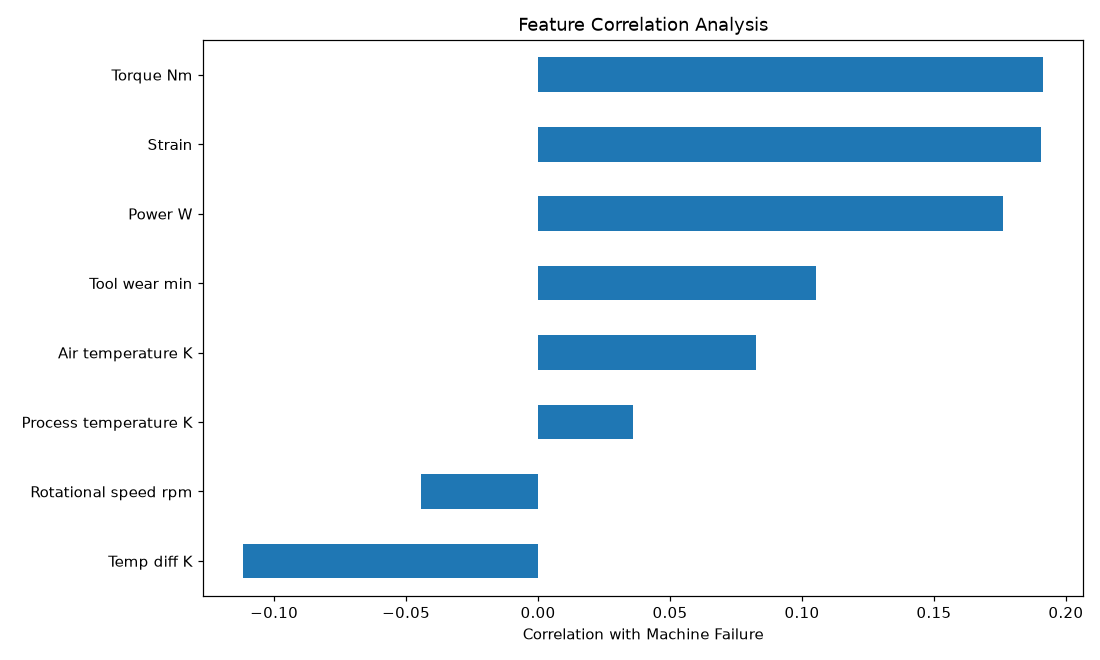

In [3]:
train.eda(df)
display(Image('reports/distributions.png'), Image('reports/correlations.png'))

## Step 4: Preprocessing
* The failure-mode flags (TWF, HDF, PWF, OSF, RNF) are dropped because they **leak the target**.
* The data is split **before** any undersampling, so the test set keeps the real 3.4% failure rate.

In [4]:
X_train, X_test, y_train, y_test, X_bal, y_bal = train.preprocess(df)


Original class distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Undersampled training distribution:
Machine failure
0    271
1    271
Name: count, dtype: int64
Train: 8000 rows (542 undersampled) | Test: 2000 rows (3.40% failures)


## Step 5: The guide's 3 models (trained on undersampled data)

In [5]:
fitted, rows = {}, []
for name, model in train.baseline_models().items():
    model.fit(X_bal, y_bal)
    fitted[name] = model
    rows.append({'model': name, **{k: v for k, v in train.test_metrics(model, X_test, y_test, 0.5).items() if k != 'confusion_matrix'}})
pd.DataFrame(rows).set_index('model').round(3)

,roc_auc,pr_auc,threshold,accuracy,precision,recall,f1
model,,,,,,,
Logistic Regression,0.923,0.425,0.5,0.841,0.158,0.853,0.267
Random Forest,0.978,0.680,0.5,0.908,0.264,0.956,0.414
XGBoost,0.976,0.704,0.5,0.920,0.291,0.941,0.444


## Beyond the guide: tuned, class-weighted XGBoost
This model trains on **all** training rows and handles the imbalance with `scale_pos_weight`, instead of throwing away 94% of the healthy machines. Hyperparameters are tuned for average precision. The alert threshold is then chosen by cross-validation on the training data only, to reach recall ≥ 0.85.

In [6]:
name = 'XGBoost tuned (class-weighted)'
tuned, best_params, spw = train.tune_xgboost(X_train, y_train)
fitted[name] = tuned
threshold = train.choose_threshold(tuned, X_train, y_train)
final = train.test_metrics(tuned, X_test, y_test, threshold)
final


Tuned XGBoost: CV average precision = 0.8680
Best params: {'subsample': 1.0, 'reg_lambda': 3, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.85}


Chosen threshold for recall >= 0.85: 0.2791


{'roc_auc': 0.985537693338205,
 'pr_auc': 0.8876725495391644,
 'threshold': 0.27905750274658203,
 'accuracy': 0.9805,
 'precision': 0.6666666666666666,
 'recall': 0.8529411764705882,
 'f1': 0.7483870967741936,
 'confusion_matrix': {'tn': 1903, 'fp': 29, 'fn': 10, 'tp': 58}}

## Step 6: Evaluation & explanation

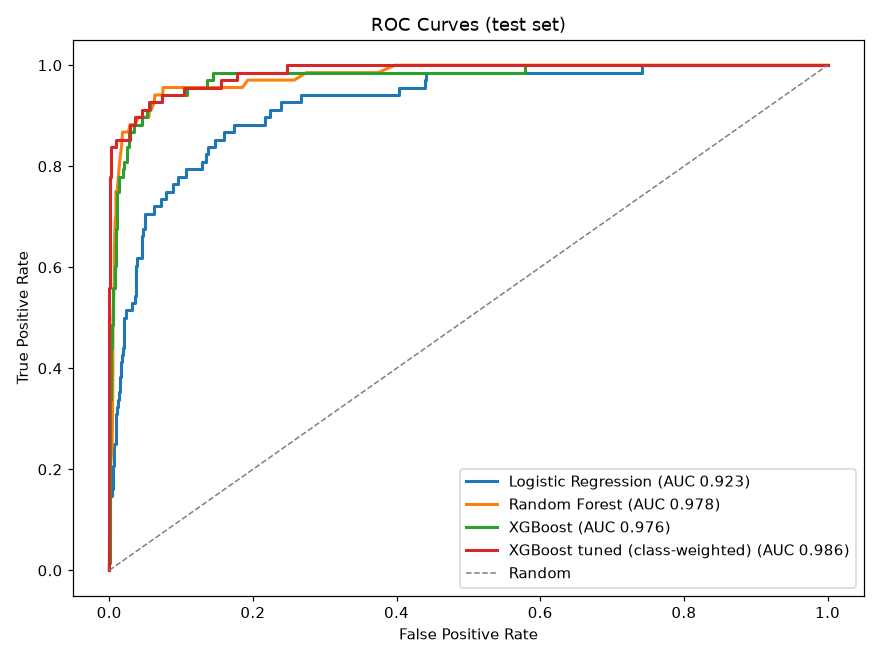

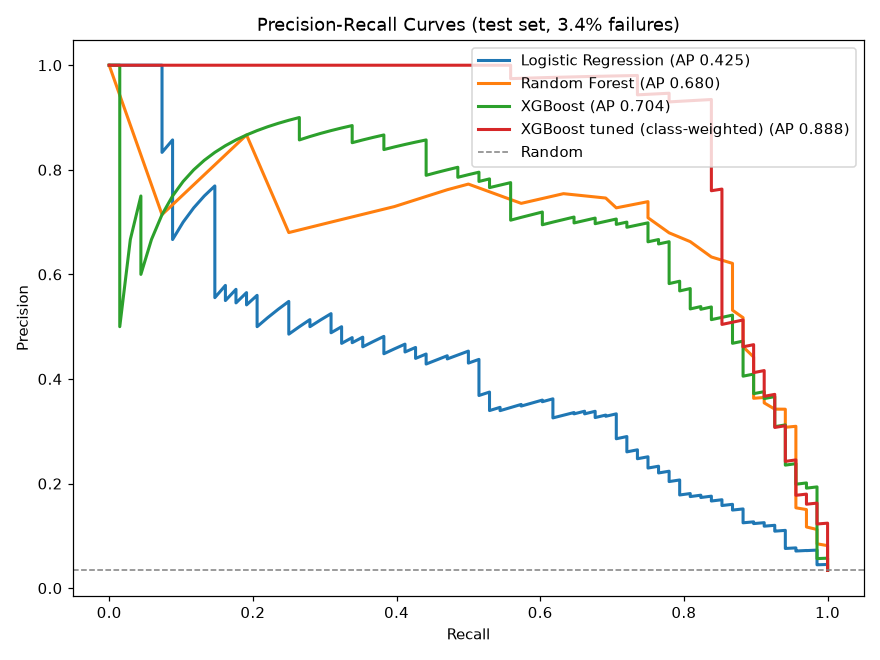

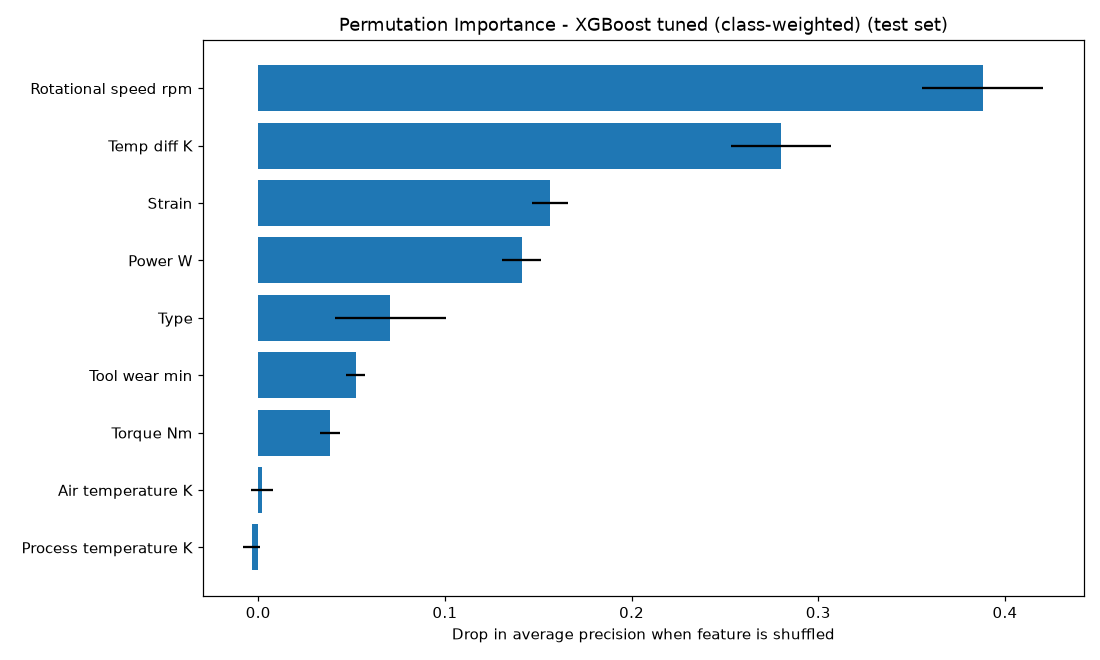

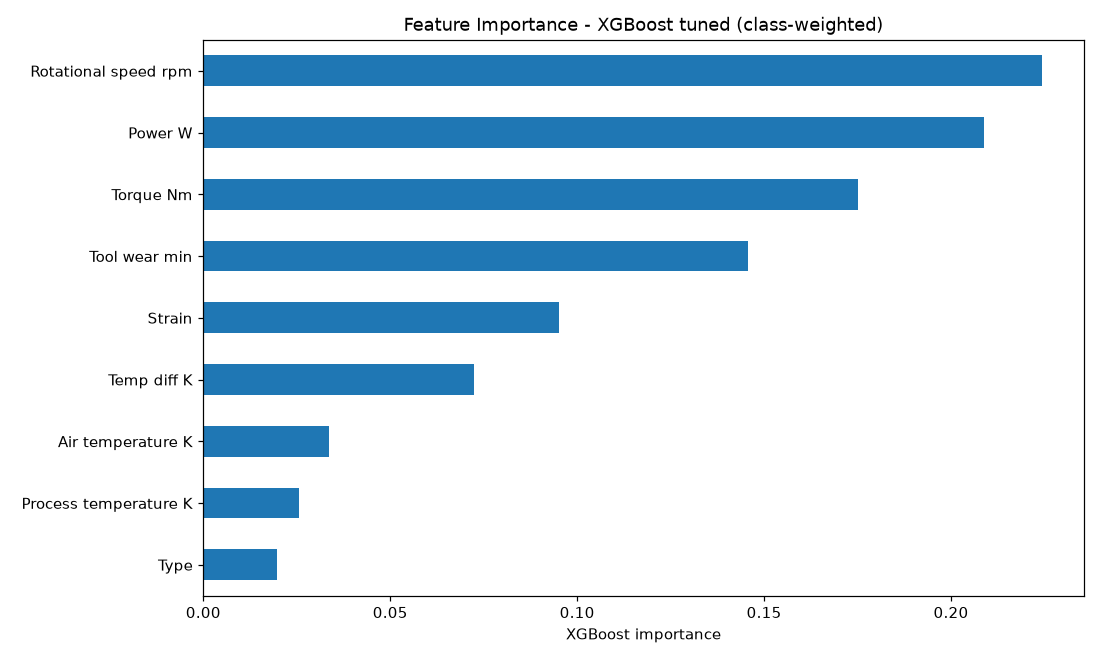

,Feature,Importance,Std
3,Rotational speed rpm,0.388124,0.032489
7,Temp diff K,0.280024,0.026705
8,Strain,0.156327,0.009595
6,Power W,0.141043,0.010332
0,Type,0.070816,0.029842
5,Tool wear min,0.052207,0.005118
4,Torque Nm,0.038433,0.005464
1,Air temperature K,0.002061,0.005909
2,Process temperature K,-0.003574,0.004383


In [7]:
perm = train.plots(fitted, name, X_test, y_test)
for img in ['roc_curve', 'pr_curve', 'permutation_importance', 'feature_importance']:
    display(Image(f'reports/{img}.png'))
perm

## Steps 7–8: Score new machines with the saved model
(`train.py` saves the model; `predict.py` adds the engineered features and applies the alert threshold.)

In [8]:
test = pd.read_csv('reports/test_set.csv')
sample = pd.concat([test[test['Machine failure'] == 1].head(3), test[test['Machine failure'] == 0].head(3)])
sample[predict.RAW_FEATURES + ['Machine failure']].join(predict.predict_failure_risk(sample))

,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,failure_probability,risk_level,alert
17,0,303.7,312.1,1363,51.8,90,1,0.9509,High,True
21,0,298.9,310.2,2737,8.8,142,1,0.9867,High,True
40,0,302.6,310.4,1359,57.2,67,1,0.9984,High,True
0,0,300.5,309.8,1345,62.7,153,0,0.0196,Low,False
1,0,303.7,312.4,1513,40.1,135,0,0.0003,Low,False
2,0,302.5,311.4,1559,37.6,209,0,0.4815,Medium,True
